# **Sentiment Analysis for Mental Health**

### **Importing Dependencies**

In [1]:
# Print all the outputs in a cell
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

import warnings
warnings.simplefilter("ignore")
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", message=".*no associated frequency information.*")
warnings.filterwarnings("ignore", message=".*Maximum Likelihood optimization failed to converge.*")

import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.pyplot as pyplot
import seaborn as sns
import re

# NLTK Libraries
import nltk
from nltk.corpus import stopwords

# Scikit-Learn Libraries 
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Keras / Tensorflow Libraries
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import gensim
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Input, Embedding, LSTM, Dense, Dropout, SpatialDropout1D
from keras.initializers import Constant
from tensorflow.keras.regularizers import l2
from sklearn.utils import class_weight
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

### **Dataset Setup**

**Step 1: Setting the Directory**

In [2]:
# Base Directory
base_dir = '/Users/reemikadas/Desktop/SCU MSBA/Github/Data_Science/NLP_Projects/NLP | Sentiment Analysis for Mental Health'

# Data Directory
data_dir = os.path.join(base_dir, 'Data')
data_csv_path = os.path.join(data_dir, 'sentiment_health_cleaned.csv')

**Step 2: Loading and Reading the Datasets**

In [3]:
# Loading the DataFrame
df = pd.read_csv(data_csv_path)

# Glimpse of the first 5 rows
df.head()

,unique_id,statement,status
0,0,oh my gosh,Anxiety
1,1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,3,I've shifted my focus to something else but I'...,Anxiety
4,4,"I'm restless and restless, it's been a month n...",Anxiety


### **Text Preprocessing [Lowercase, Stopwords Removal, Punctuations, Special Characters, Digits, URLS]**

**Example**

----------------------------------------------------------------------------

In [4]:
# Text sample
text = df['statement'].values[3]
text

"I've shifted my focus to something else but I'm still worried"

In [5]:
# Lowercase the sentence
text = text.lower()
text

"i've shifted my focus to something else but i'm still worried"

In [6]:
# Stopwords
stop_words = set(stopwords.words('english'))

# View 20 stopwords
stop_words

{'a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 "he's",
 'her',
 'here',
 'hers',
 'herself',
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 "i'll",
 "i'm",
 "i've",
 'if',
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [7]:
# Remove Stopwords
text = ' '.join([w for w in text.split() if w not in stop_words])
text

'shifted focus something else still worried'

In [8]:
# Remove URLs (if any)
text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
text

'shifted focus something else still worried'

In [9]:
# Remove Special characters and numbers
text = re.sub(r'[^a-z\s]', '', text)
text

'shifted focus something else still worried'

In [10]:
# Remove Whitespace
text = re.sub(r'\s+', ' ', text).strip()
text

'shifted focus something else still worried'

---------------------------------------------------------------------------------------------------------------

Define function to apply text preprocessing on whole datasets.

In [11]:
# Text Preprocessing function

def text_preprocess(text):
    # Lowercase
    text = text.lower()

    # Remove stopwords
    text = ' '.join([word for word in text.split() if word not in stop_words])
    
    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    
    # Remove special characters and numbers
    text = re.sub(r'[^a-z\s]', '', text)
    
    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

In [12]:
df['clean_text'] = df['statement'].apply(text_preprocess)

# Glimpse of the data
df.head(10)

,unique_id,statement,status,clean_text
0,0,oh my gosh,Anxiety,oh gosh
1,1,"trouble sleeping, confused mind, restless hear...",Anxiety,trouble sleeping confused mind restless heart ...
2,2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety,wrong back dear forward doubt stay restless re...
3,3,I've shifted my focus to something else but I'...,Anxiety,shifted focus something else still worried
4,4,"I'm restless and restless, it's been a month n...",Anxiety,restless restless month now boy mean
5,5,"every break, you must be nervous, like somethi...",Anxiety,every break must nervous like something wrong ...
6,6,"I feel scared, anxious, what can I do? And may...",Anxiety,feel scared anxious do may family us protected
7,7,Have you ever felt nervous but didn't know why?,Anxiety,ever felt nervous know why
8,8,"I haven't slept well for 2 days, it's like I'm...",Anxiety,slept well days like restless huh
9,9,"I'm really worried, I want to cry.",Anxiety,really worried want cry


In [13]:
# Convert the Sentiment Status text to numbers --> eg: 'Anxiety:0', 'Bipolar:1', etc.
label_encoder = LabelEncoder()
df['label_encoded'] = label_encoder.fit_transform(df['status'])

# check mapping
label_map = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print(label_map)

{'Anxiety': np.int64(0), 'Bipolar': np.int64(1), 'Depression': np.int64(2), 'Normal': np.int64(3), 'Personality disorder': np.int64(4), 'Stress': np.int64(5), 'Suicidal': np.int64(6)}


In [14]:
# Glimpse of the data
df.head()

,unique_id,statement,status,clean_text,label_encoded
0,0,oh my gosh,Anxiety,oh gosh,0
1,1,"trouble sleeping, confused mind, restless hear...",Anxiety,trouble sleeping confused mind restless heart ...,0
2,2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety,wrong back dear forward doubt stay restless re...,0
3,3,I've shifted my focus to something else but I'...,Anxiety,shifted focus something else still worried,0
4,4,"I'm restless and restless, it's been a month n...",Anxiety,restless restless month now boy mean,0


In [15]:
# Keep the required columns (clean_text, label_encoded)
clean_df = df[['clean_text', 'label_encoded']]

# Glimpse of the Clean Df
clean_df.head()

,clean_text,label_encoded
0,oh gosh,0
1,trouble sleeping confused mind restless heart ...,0
2,wrong back dear forward doubt stay restless re...,0
3,shifted focus something else still worried,0
4,restless restless month now boy mean,0


### **Split the Data**

In [16]:
# Define independent (X) and dependent (y) variables
X = clean_df['clean_text']
y = clean_df['label_encoded']

# Split the data into Train and test Data

# Train + Temp (Val + Test)
X_train, X_temp, y_train, y_temp = train_test_split(
                                                    X, y,
                                                    test_size = 0.3,
                                                    stratify = y, random_state = 42
                                                    )

# Val + Test
X_val, X_test, y_val, y_test = train_test_split(
                                                    X_temp, y_temp,
                                                    test_size = 0.5,
                                                    stratify = y_temp, random_state = 42
                                                    )

# Print the size of train / val / test sets
print("Train Set: {}".format(len(X_train)))
print("Validation Set: {}".format(len(X_val)))
print("Test Set: {}".format(len(X_test)))

Train Set: 36876
Validation Set: 7902
Test Set: 7903


### **Text Preprocessing [Tokenization, Padding]**

**(a) Tokenization**

- **'total_words'** denotes the top maximum words size
- **'OOV'**: Stands for 'Out-of-Vocabulary'. These are words that don’t appear in the tokenizer’s vocabulary (i.e., words that weren’t seen during training or are beyond the num_words limit). Any word not in the top num_words gets replaced by OOV often represented as '1'.

In [17]:
# Tokenizer
total_words = 20000

tokenizer = Tokenizer(num_words = total_words, oov_token = "<OOV>")
tokenizer.fit_on_texts(X_train)

# Vocabulary Size
vocab_size = len(tokenizer.word_index)
print(vocab_size)

59722


In [18]:
# Print the words based high to low frequency
print(tokenizer.word_index)

{'<OOV>': 1, 'like': 2, 'feel': 3, 'want': 4, 'know': 5, 'life': 6, 'get': 7, 'even': 8, 'time': 9, 'would': 10, 'people': 11, 'really': 12, 'cannot': 13, 'me': 14, 'one': 15, 'going': 16, 'think': 17, 'it': 18, 'go': 19, 'much': 20, 'never': 21, 'day': 22, 'help': 23, 'im': 24, 'anymore': 25, 'could': 26, 'things': 27, 'years': 28, 'anxiety': 29, 'back': 30, 'anything': 31, 'work': 32, 'take': 33, 'still': 34, 'something': 35, 'make': 36, 'depression': 37, 'got': 38, 'always': 39, 'friends': 40, 'good': 41, 'feeling': 42, 'anyone': 43, 'way': 44, 'everything': 45, 'better': 46, 'see': 47, 'need': 48, 'every': 49, 'nothing': 50, 'someone': 51, 'also': 52, 'bad': 53, 'year': 54, 'family': 55, 'since': 56, 'right': 57, 'hate': 58, 'last': 59, 'thing': 60, 'live': 61, 'fucking': 62, 'die': 63, 'job': 64, 'love': 65, 'getting': 66, 'end': 67, 'ever': 68, 'talk': 69, 'everyone': 70, 'this': 71, 'thought': 72, 'lot': 73, 'trying': 74, 'say': 75, 'long': 76, 'tired': 77, 'try': 78, 'keep': 79

In [19]:
# Convert text to sequences
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq = tokenizer.texts_to_sequences(X_val)
X_test_seq = tokenizer.texts_to_sequences(X_test)

# Few Sample Texts (first 5 Statements)
print(X_train_seq[:5])

[[180, 1586, 145, 27, 6, 185, 624, 172, 232, 141, 5266, 453, 814, 1885, 1826, 21, 97, 55, 1170, 29, 131, 221, 2772, 2, 550, 719, 290, 27, 2, 278, 168, 27, 473, 212, 200, 295, 52, 130, 263, 2773, 41, 194, 17, 2, 80, 125, 143, 182, 9, 1184, 80, 187, 2230, 8639, 118, 150, 142, 143, 72, 269, 165, 2536, 245, 34, 118, 80, 790, 325, 45, 283, 470, 38, 502, 118, 4562, 612, 172, 535, 163, 1440, 1738, 34, 376, 34, 143, 118, 55, 41, 1420, 266, 34, 17, 143, 182, 2, 165, 1, 192, 93, 3, 2, 2, 172, 61, 165, 2, 501, 681, 143, 185, 7, 342, 567, 329, 139, 93, 417, 1325, 3, 73, 650, 17, 93, 34, 7, 158, 17, 143, 110, 7, 23, 491, 91, 1639, 126, 33, 1119, 2, 1977, 1119, 1269, 20, 719, 35, 491, 171, 146, 73, 2475, 126, 632, 314, 41, 222, 1229, 90, 9147, 159, 41, 470, 182, 17, 143], [1, 1, 1, 2095, 1], [57, 831, 619, 67, 190, 20, 9, 150, 2, 4, 47, 161, 8, 105, 4, 36, 752, 2, 436, 600, 35, 536, 8, 659, 5846, 495, 135, 18, 74, 5, 122, 850, 203, 1392, 43, 65, 1, 105, 40, 16, 115, 277], [424, 353], [48, 390, 148]]

In [20]:
word_to_id = tokenizer.word_index
id_to_word = {value:key for key, value in word_to_id.items()}

# Example
print(word_to_id['life'])
print(id_to_word[6])

6
life


**(b) Padding**

In [21]:
num_tokens = [len(tokens) for tokens in X_train_seq]
num_tokens = np.array(num_tokens)

print("Average Tokens per Statement: {}".format(np.mean(num_tokens)))
print("Max Tokens in a Statement: {}".format(np.max(num_tokens)))

Average Tokens per Statement: 53.22857685215316
Max Tokens in a Statement: 3780


In [22]:
# Maximum length of words in a Statements = Average + 2 * Standard Deviations
max_tokens = np.mean(num_tokens) + 2 * np.std(num_tokens)
max_tokens = int(max_tokens)
print("Maximum number of tokens per statement: {}".format(max_tokens))

Maximum number of tokens per statement: 208


In [23]:
np.sum(num_tokens < max_tokens)/ len(num_tokens) 

np.float64(0.962956936761037)

This covers about 96% of the data-set.

In [24]:
# Padding
X_train_pad = pad_sequences(X_train_seq,
                            maxlen = max_tokens,
                            padding = 'pre', # Adding 0 at the beginning (words < 208)
                            truncating = 'pre' # Removing words from the beginning (words > 208)
                           )

X_val_pad = pad_sequences(X_val_seq,
                          maxlen = max_tokens,
                          padding = 'pre', # Adding 0 at the beginning (words < 208)
                          truncating = 'pre' # Removing words from the beginning (words > 208)
                          )

X_test_pad = pad_sequences(X_test_seq,
                           maxlen = max_tokens,
                           padding = 'pre', # Adding 0 at the beginning (words < 208)
                           truncating = 'pre' # Removing words from the beginning (words > 208)
                          )

# Print the shape after padding
print("Train Data Shape after Padding: {}".format(X_train_pad.shape))
print("Validation Data Shape after Padding: {}".format(X_val_pad.shape))
print("Test Data Shape after Padding: {}".format(X_test_pad.shape))

Train Data Shape after Padding: (36876, 208)
Validation Data Shape after Padding: (7902, 208)
Test Data Shape after Padding: (7903, 208)


In [25]:
# First Statement (Original Clean Text)
X_train.iloc[0]

'put context though things life probably explain another post little summary kid nearly raped cousin never told family grew anxiety parents bit strict like physically harm saying things like stupid kind things child i understand mother also mental issues cured good relationship think like started thinking suicide sad time yo started self harming mitigate thoughts left sometimes suicide thought came mind studied college still thoughts started dating girl everything okay whenever got fight thoughts appeared moving another country start graduate studies still girlfriend still suicide thoughts family good terms close still think suicide sad like mind imagines place happy feel like like another live mind like oh yeah suicide probably get there despite fact actually happy whatever doing feel lot pressure think happy still get times think suicide tried get help psychiatrist first session wanted take lithium like wtf lithium causes much harm something psychiatrist used give lot patients wanted

In [26]:
# First Statement before Padding
np.array(X_train_seq[0])

array([ 180, 1586,  145,   27,    6,  185,  624,  172,  232,  141, 5266,
        453,  814, 1885, 1826,   21,   97,   55, 1170,   29,  131,  221,
       2772,    2,  550,  719,  290,   27,    2,  278,  168,   27,  473,
        212,  200,  295,   52,  130,  263, 2773,   41,  194,   17,    2,
         80,  125,  143,  182,    9, 1184,   80,  187, 2230, 8639,  118,
        150,  142,  143,   72,  269,  165, 2536,  245,   34,  118,   80,
        790,  325,   45,  283,  470,   38,  502,  118, 4562,  612,  172,
        535,  163, 1440, 1738,   34,  376,   34,  143,  118,   55,   41,
       1420,  266,   34,   17,  143,  182,    2,  165,    1,  192,   93,
          3,    2,    2,  172,   61,  165,    2,  501,  681,  143,  185,
          7,  342,  567,  329,  139,   93,  417, 1325,    3,   73,  650,
         17,   93,   34,    7,  158,   17,  143,  110,    7,   23,  491,
         91, 1639,  126,   33, 1119,    2, 1977, 1119, 1269,   20,  719,
         35,  491,  171,  146,   73, 2475,  126,  6

In [27]:
# First Statement after Padding
np.array(X_train_pad[0])

array([   0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,  180, 1586,  145,   27,    6,  185,  624,  172,  232,  141,
       5266,  453,  814, 1885, 1826,   21,   97,   55, 1170,   29,  131,
        221, 2772,    2,  550,  719,  290,   27,    2,  278,  168,   27,
        473,  212,  200,  295,   52,  130,  263, 2773,   41,  194,   17,
          2,   80,  125,  143,  182,    9, 1184,   80,  187, 2230, 8639,
        118,  150,  142,  143,   72,  269,  165, 2536,  245,   34,  118,
         80,  790,  325,   45,  283,  470,   38,  502,  118, 4562,  612,
        172,  535,  163, 1440, 1738,   34,  376,   34,  143,  118,   55,
         41, 1420,  266,   34,   17,  143,  182,    2,  165,    1,  192,
         93,    3,    2,    2,  172,   61,  165,   

### **Feature Extraction [Word2Vec Embedding - Custom]**

In [28]:
# Creating word list
X_train_wordlist = [[id_to_word[token] for token in review_tokens] for review_tokens in X_train_seq]
X_test_wordlist = [[id_to_word[token] for token in review_tokens] for review_tokens in X_test_seq]

# Print the first statement
print(X_train_wordlist[0])

['put', 'context', 'though', 'things', 'life', 'probably', 'explain', 'another', 'post', 'little', 'summary', 'kid', 'nearly', 'raped', 'cousin', 'never', 'told', 'family', 'grew', 'anxiety', 'parents', 'bit', 'strict', 'like', 'physically', 'harm', 'saying', 'things', 'like', 'stupid', 'kind', 'things', 'child', 'i', 'understand', 'mother', 'also', 'mental', 'issues', 'cured', 'good', 'relationship', 'think', 'like', 'started', 'thinking', 'suicide', 'sad', 'time', 'yo', 'started', 'self', 'harming', 'mitigate', 'thoughts', 'left', 'sometimes', 'suicide', 'thought', 'came', 'mind', 'studied', 'college', 'still', 'thoughts', 'started', 'dating', 'girl', 'everything', 'okay', 'whenever', 'got', 'fight', 'thoughts', 'appeared', 'moving', 'another', 'country', 'start', 'graduate', 'studies', 'still', 'girlfriend', 'still', 'suicide', 'thoughts', 'family', 'good', 'terms', 'close', 'still', 'think', 'suicide', 'sad', 'like', 'mind', '<OOV>', 'place', 'happy', 'feel', 'like', 'like', 'anoth

In [29]:
# Defining the dimension of embedding
emb_dim = 32

# Initiate the embedding model
emb_model = gensim.models.Word2Vec(
                                    sentences = X_train_wordlist,
                                    vector_size = emb_dim,
                                    window = 5, # 5 words before and after the concentrated word
                                    sg = 1, # Skip-grams order doesn't matter
                                  )

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


In [30]:
# Unique words learned by Word2Vec
len(list(emb_model.wv.key_to_index))

13569

In [31]:
# Example: Similar words wrt 'Mental'
emb_model.wv.most_similar('mental')

[('health', 0.919955849647522),
 ('illness', 0.863345742225647),
 ('illnesses', 0.8544543385505676),
 ('declining', 0.8515092730522156),
 ('deteriorating', 0.840003490447998),
 ('professionals', 0.8225834965705872),
 ('issues', 0.8157738447189331),
 ('stigma', 0.8074575066566467),
 ('struggles', 0.8068000078201294),
 ('ongoing', 0.7906830310821533)]

In [32]:
# Vector for word 'Mental'
emb_model.wv.get_vector('mental')

array([-0.4362351 , -0.9686804 ,  0.27522808,  0.2508917 , -0.5566655 ,
       -0.13639933,  0.34225786,  0.44878063, -0.14611797, -0.19515617,
       -0.23928632, -0.39928216,  0.55427134, -0.31986666,  0.05612099,
       -0.24149933, -0.47317797, -0.5707588 ,  0.589991  ,  0.3819161 ,
        0.7254011 ,  0.488639  , -0.08105964,  0.11932453, -0.4194308 ,
        0.2790422 , -0.7456069 ,  0.1927451 ,  0.47929093, -0.39632964,
       -0.9126523 ,  0.7330981 ], dtype=float32)

In [33]:
# Embedding Matrix
emb_matrix = np.zeros((total_words, emb_dim))

for idx, key in enumerate(emb_model.wv.key_to_index):
    token_id = word_to_id[key]
    emb_matrix[token_id] = emb_model.wv.get_vector(key)

In [34]:
# Word 'Mental'
word_to_id['mental']

130

In [35]:
emb_matrix[130]

array([-0.4362351 , -0.96868038,  0.27522808,  0.25089169, -0.55666548,
       -0.13639933,  0.34225786,  0.44878063, -0.14611797, -0.19515617,
       -0.23928632, -0.39928216,  0.55427134, -0.31986666,  0.05612099,
       -0.24149933, -0.47317797, -0.57075882,  0.58999097,  0.38191611,
        0.7254011 ,  0.488639  , -0.08105964,  0.11932453, -0.41943079,
        0.27904221, -0.7456069 ,  0.1927451 ,  0.47929093, -0.39632964,
       -0.91265231,  0.73309809])

### **Model Development**

#### **Recurrent Neural Network (LSTM)**

In [36]:
# --- LSTM Architecture ---
# 1. max_tokens = 208
# 2. total_words = 20000
# 3. emb_dim = 32
lstm_node_1 = 64
num_classes = len(np.unique(y_train)) # 7 classes

# Initiate the Model
lstm_model = Sequential()

# Input Layer
lstm_model.add(Input(shape = (max_tokens,)))

# Embedding Layer
lstm_model.add(Embedding(
                            input_dim = total_words,
                            output_dim = emb_dim,
                            embeddings_initializer = Constant(emb_matrix),
                            trainable = True,
                            name = 'embedding'
                        ))
lstm_model.add(SpatialDropout1D(0.3))

# LSTM Layer 1
lstm_model.add(LSTM(units = lstm_node_1, return_sequences = False, dropout = 0.4, recurrent_dropout = 0.3))
lstm_model.add(Dropout(0.3))

# Output Layer
lstm_model.add(Dense(num_classes, activation = 'softmax', kernel_regularizer=l2(0.001)))

# Print the Model Summary
lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 208, 32)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 208, 32)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 665,287 (2.54 MB)

 Trainable params: 665,287 (2.54 MB)

 Non-trainable params: 0 (0.00 B)

In [38]:
# Compile the Model
grad_desc = keras.optimizers.Adam(learning_rate = 1e-3)
loss_function = 'sparse_categorical_crossentropy'
performance = ['accuracy']
num_iter = 20
batch_num = 64

lstm_model.compile(optimizer = grad_desc, loss = loss_function, metrics = performance)

# Class Weights
class_weights = class_weight.compute_class_weight(
                                                    class_weight = 'balanced',
                                                    classes = np.unique(y_train),
                                                    y = y_train
                                                )
class_weights = dict(enumerate(class_weights))

# --- Callbacks ---
callback = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,        # reduce LR by 50%
    patience=2,
    min_lr=1e-6,
    verbose=1
)

# Fit the Model
lstm_history = lstm_model.fit(
                                X_train_pad, y_train,
                                validation_data = (X_val_pad, y_val),
                                epochs = num_iter,
                                batch_size = batch_num,
                                class_weight = class_weights,
                                callbacks = [callback, reduce_lr]
                            )

Epoch 1/20
577/577 ━━━━━━━━━━━━━━━━━━━━ 56s 93ms/step - accuracy: 0.4227 - loss: 1.6537 - val_accuracy: 0.5623 - val_loss: 1.1735 - learning_rate: 0.0010
Epoch 2/20
577/577 ━━━━━━━━━━━━━━━━━━━━ 53s 91ms/step - accuracy: 0.5214 - loss: 1.4038 - val_accuracy: 0.5947 - val_loss: 0.9929 - learning_rate: 0.0010
Epoch 3/20
577/577 ━━━━━━━━━━━━━━━━━━━━ 53s 91ms/step - accuracy: 0.5751 - loss: 1.2182 - val_accuracy: 0.6354 - val_loss: 0.9113 - learning_rate: 0.0010
Epoch 4/20
577/577 ━━━━━━━━━━━━━━━━━━━━ 53s 92ms/step - accuracy: 0.6113 - loss: 1.0718 - val_accuracy: 0.6587 - val_loss: 0.8920 - learning_rate: 0.0010
Epoch 5/20
577/577 ━━━━━━━━━━━━━━━━━━━━ 54s 93ms/step - accuracy: 0.6361 - loss: 0.9761 - val_accuracy: 0.6646 - val_loss: 0.8644 - learning_rate: 0.0010
Epoch 6/20
577/577 ━━━━━━━━━━━━━━━━━━━━ 55s 95ms/step - accuracy: 0.6603 - loss: 0.8987 - val_accuracy: 0.6989 - val_loss: 0.7952 - learning_rate: 0.0010
Epoch 7/20
577/577 ━━━━━━━━━━━━━━━━━━━━ 54s 93ms/step - accuracy: 0.6768 - l

In [39]:
# History Table
lstm_history_df = pd.DataFrame(lstm_history.history)
lstm_history_df.rename(columns = {'loss':'train_loss', 'accuracy':'train_accuracy'}, inplace = True)

lstm_history_df

,train_accuracy,train_loss,val_accuracy,val_loss,learning_rate
0,0.422687,1.653699,0.562263,1.173523,0.001000
1,0.521369,1.403781,0.594660,0.992912,0.001000
2,0.575117,1.218223,0.635409,0.911301,0.001000
3,0.611265,1.071789,0.658694,0.892015,0.001000
4,0.636132,0.976123,0.664642,0.864351,0.001000
5,0.660348,0.898672,0.698937,0.795155,0.001000
6,0.676782,0.843280,0.680334,0.832499,0.001000
7,0.689744,0.798424,0.694761,0.814361,0.001000
8,0.701106,0.764985,0.706277,0.773751,0.000500
9,0.705933,0.735171,0.716274,0.744291,0.000500


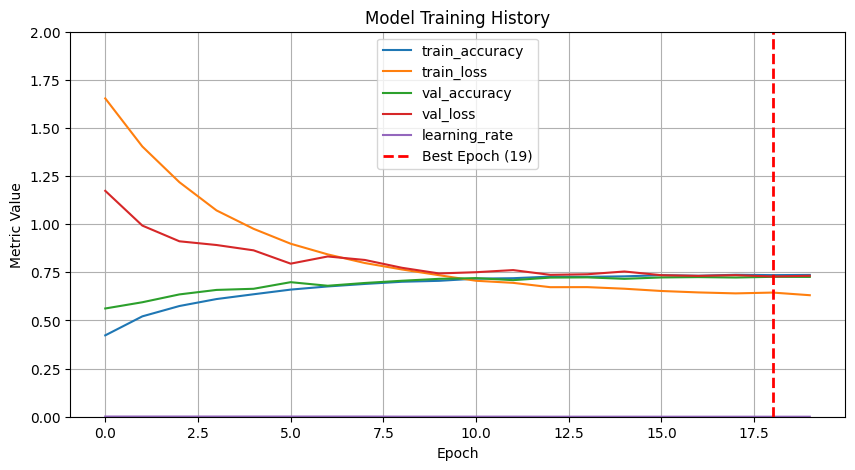

In [40]:
def plot_loss_acc(history_df, ylim_x=0, ylim_y=2):
    best_epoch_index = history_df['val_loss'].idxmin()
    history_df.plot(figsize=(10, 5))

    pyplot.axvline(
        x=best_epoch_index, 
        color='r', 
        linestyle='--', 
        linewidth=2,
        label=f'Best Epoch ({best_epoch_index + 1})'
    )
    
    pyplot.gca().set_ylim(ylim_x, ylim_y)
    pyplot.title('Model Training History')
    pyplot.xlabel('Epoch')
    pyplot.ylabel('Metric Value')
    pyplot.legend()
    pyplot.grid(True)
    pyplot.show()

plot_loss_acc(lstm_history_df, ylim_x=0, ylim_y=2)

In [ ]:
# Find the row with the minimum validation loss
#best_epoch_row = lstm_history_df.loc[lstm_history_df['val_loss'].idxmin()]

# Extract the Accuracy of Training and Validation
#best_train_accuracy = best_epoch_row['train_accuracy']
#best_val_accuracy = best_epoch_row['val_accuracy']

# Print the Result
#print("Training Accuracy: {:.2f}%".format(best_train_accuracy*100.0))
#print("Validation Accuracy: {:.2f}%".format(best_val_accuracy*100.0))

**Evaluate on Test Data**

In [42]:
# Evaluate on Training Set
train_loss, train_acc = lstm_model.evaluate(X_train_pad, y_train, verbose=0)
print("Training Accuracy: {:.2f}%".format(train_acc*100.0))

# Evaluate on Validation Set
val_loss, val_acc = lstm_model.evaluate(X_val_pad, y_val, verbose=0)
print("Validation Accuracy: {:.2f}%".format(val_acc*100.0))

Training Accuracy: 77.43%
Validation Accuracy: 72.68%


In [43]:
# Evaluate on Test Set
test_loss, test_acc = lstm_model.evaluate(X_test_pad, y_test, verbose=0)
print("Test Accuracy: {:.2f}%".format(test_acc*100.0))

Test Accuracy: 73.86%


In [44]:
y_hat = lstm_model.predict(X_test_pad)
y_hat.round(3)

247/247 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step


array([[0.982, 0.002, 0.002, ..., 0.   , 0.013, 0.   ],
       [0.001, 0.   , 0.001, ..., 0.   , 0.   , 0.002],
       [0.091, 0.001, 0.003, ..., 0.001, 0.009, 0.006],
       ...,
       [0.006, 0.985, 0.003, ..., 0.001, 0.003, 0.   ],
       [0.003, 0.008, 0.439, ..., 0.005, 0.012, 0.53 ],
       [0.017, 0.005, 0.008, ..., 0.006, 0.007, 0.015]], dtype=float32)

In [45]:
y_hat_class = np.argmax(y_hat, axis = 1)
y_hat_class

array([0, 3, 3, ..., 1, 6, 3])

<Figure size 800x600 with 0 Axes>

<Axes: >

Text(0.5, 36.72222222222221, 'Predicted')

Text(70.7222222222222, 0.5, 'Actual')

Text(0.5, 1.0, 'Confusion Matrix - Multi-Class Sentiment Analysis')

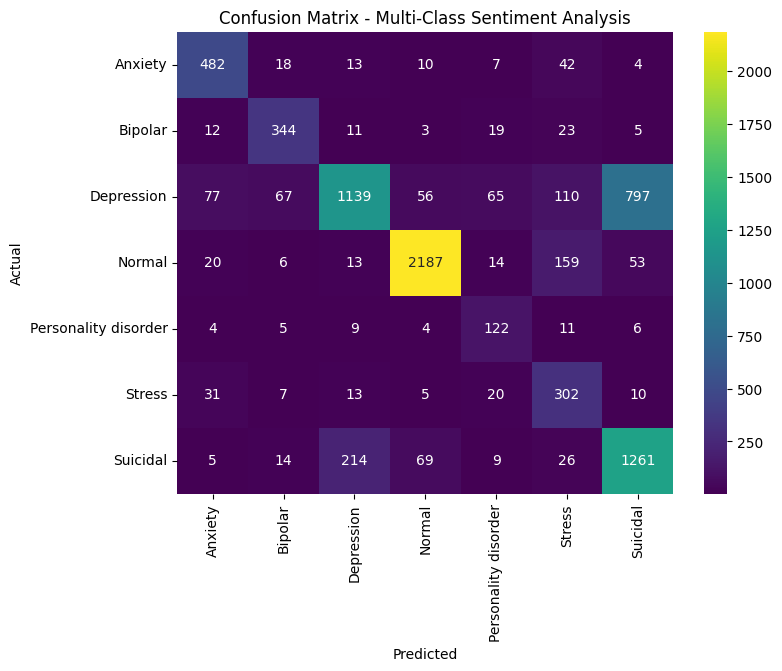

In [46]:
# Confusion Matrix
test_actual = y_test
cm = confusion_matrix(y_test, y_hat_class)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="viridis",
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Multi-Class Sentiment Analysis")
plt.show()

### Post Analysis

#### **Misclassification by the Model**

#### **Correct Classification by the Model**